In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../utils/')
import plotting_utils as pu
import uproot
import awkward as ak

In [20]:
# Load weights
e16 = np.load('../checkpoints/overfit_weights/e16_weights.npz')
e48 = np.load('../checkpoints/overfit_weights/e48_weights.npz')
e63 = np.load('../checkpoints/overfit_weights/e63_weights.npz')
# i0_s2 = np.load('../checkpoints/of-step1-tests/debug_4/weights/iteration_0_step_2.npz')
# i1_s1 = np.load('../checkpoints/of-development-runs/of_trial_5/weights/iteration_1_step_1.npz')
# i1_s2 = np.load('../checkpoints/of-development-runs/of_trial_5/weights/iteration_1_step_2.npz')
# i2_s1 = np.load('../checkpoints/of-development-runs/of_trial_5/weights/iteration_2_step_1.npz')
# i2_s2 = np.load('../checkpoints/of-development-runs/of_trial_5/weights/iteration_2_step_2.npz')

In [2]:
# Load data
f_train = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train_Mar1023.root')
f_test = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_test_Mar0723.root')
f_pd = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_Aug5_PseudoDataSRew_Apr8_1_All.root')
train_tree = f_train['OmniTree']
test_tree = f_test['OmniTree']
pd_tree = f_pd['OmniTree']

In [3]:
# Get pass190 flags
train_pass190 = ak.to_numpy(train_tree['pass190'].array())
test_pass190 = ak.to_numpy(test_tree['pass190'].array())
pd_pass190 = ak.to_numpy(pd_tree['pass190'].array())
train_truth_pass190 = ak.to_numpy(train_tree['truth_pass190'].array())
test_truth_pass190 = ak.to_numpy(test_tree['truth_pass190'].array())

In [14]:
# Get source weights
test_source_weights = ak.to_numpy(test_tree['weight'].array())
train_source_weights = ak.to_numpy(train_tree['weight'].array())
filter_train_source_weights = train_source_weights[train_pass190 == 1]

In [15]:
# Normalize source weights by sum of weights
test_source_weights = test_source_weights / np.sum(test_source_weights)
train_source_weights = train_source_weights / np.sum(train_source_weights)

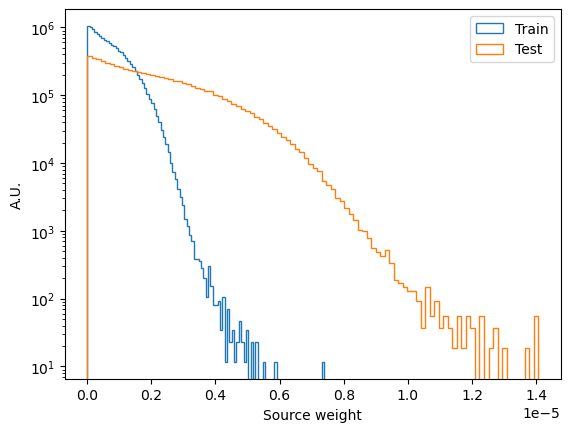

In [16]:
# Make a quick histogram of source weights
plt.hist(train_source_weights[train_pass190 == 1], bins=100, histtype='step', label='Train', density=True)
plt.hist(test_source_weights[test_pass190 == 1], bins=100, histtype='step', label='Test', density=True)
plt.yscale('log')
plt.xlabel('Source weight')
plt.ylabel('A.U.')
plt.legend()
plt.show()

In [17]:
print(np.sum(train_source_weights))
print(np.sum(test_source_weights))

0.9999998
0.99999994


In [21]:
# Get network weights
e16_test = e16['network_test']
e48_test = e48['network_test']
e63_test = e63['network_test']
# test_i1_s1_net = i1_s1['network_test']
# test_i2_s1_net = i2_s1['network_test']
e16_train = e16['network_train']
e48_train = e48['network_train']
e63_train = e63['network_train']
# train_i1_s1_net = i1_s1['network_train']
# train_i2_s1_net = i2_s1['network_train']

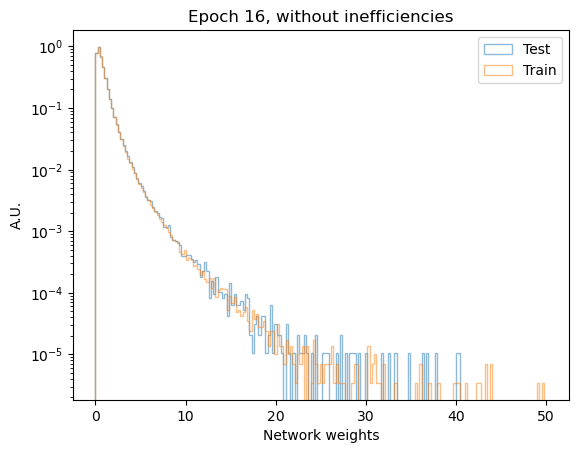

In [13]:
# Make a plot of the i0_s1 and i1_s1 network weights for testing set
bins = np.linspace(0, 50, 200)
plt.hist(e16_test, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
plt.hist(e16_train, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Network weights')
plt.title('Epoch 16, without inefficiencies')
plt.legend()
plt.show()

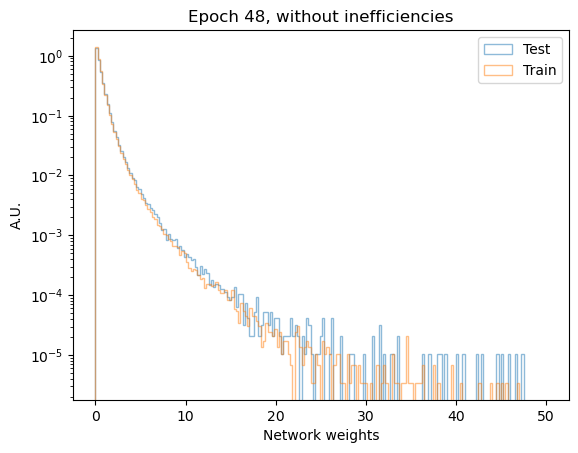

In [17]:
# Make a plot of the i0_s1 and i1_s1 network weights for testing set
bins = np.linspace(0, 50, 200)
plt.hist(e48_test, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
plt.hist(e48_train, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Network weights')
plt.title('Epoch 48, without inefficiencies')
plt.legend()
plt.show()

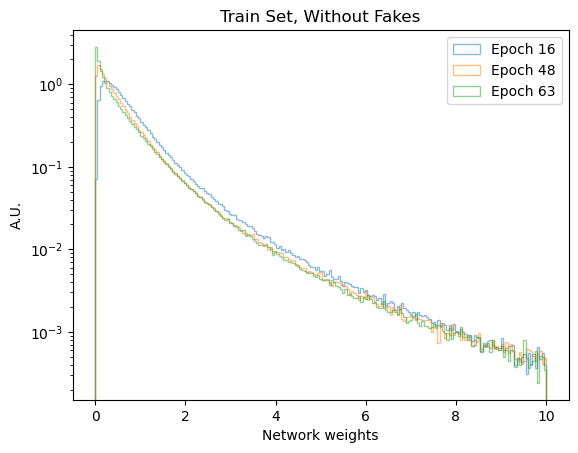

In [29]:
bins = np.linspace(0, 10, 200)
plt.hist(e16_train, bins=bins, density=True, histtype='step', label='Epoch 16', alpha=0.5)
plt.hist(e48_train, bins=bins, density=True, histtype='step', label='Epoch 48', alpha=0.5)
plt.hist(e63_train, bins=bins, density=True, histtype='step', label='Epoch 63', alpha=0.5)
plt.yscale('log')
# plt.xscale('log')
plt.ylabel('A.U.')
plt.xlabel('Network weights')
plt.title('Train Set, Without Fakes')
plt.legend()
plt.show()

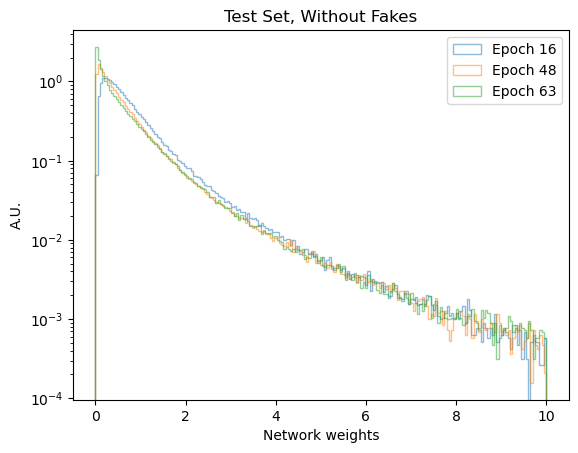

In [30]:
bins = np.linspace(0, 10, 200)
plt.hist(e16_test, bins=bins, density=True, histtype='step', label='Epoch 16', alpha=0.5)
plt.hist(e48_test, bins=bins, density=True, histtype='step', label='Epoch 48', alpha=0.5)
plt.hist(e63_test, bins=bins, density=True, histtype='step', label='Epoch 63', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Network weights')
plt.title('Test Set, Without Fakes')
plt.legend()
plt.show()

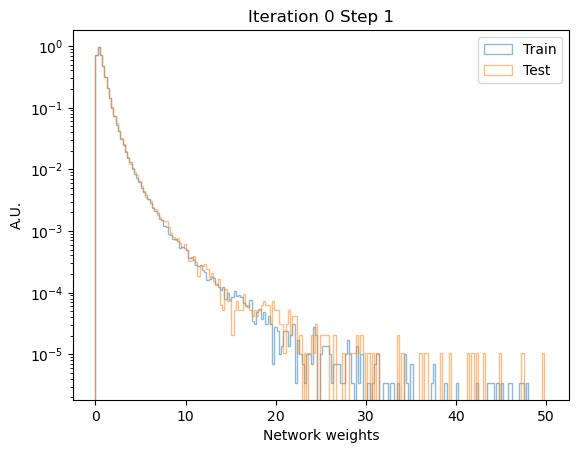

In [20]:
bins = np.linspace(0, 50, 200)
plt.hist(train_i0_s1_net, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
plt.hist(test_i0_s1_net, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Network weights')
plt.title('Iteration 0 Step 1')
plt.legend()
plt.show()

# bins = np.linspace(0, 20, 200)
# plt.hist(train_i1_s1_net, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
# plt.hist(test_i1_s1_net, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
# plt.yscale('log')
# plt.ylabel('A.U.')
# plt.xlabel('Network weights')
# plt.title('Iteration 1 Step 1')
# plt.legend()
# plt.show()

# bins = np.linspace(0, 6, 200)
# plt.hist(train_i2_s1_net, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
# plt.hist(test_i2_s1_net, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
# plt.yscale('log')
# plt.ylabel('A.U.')
# plt.xlabel('Network weights')
# plt.title('Iteration 2 Step 1')
# plt.legend()
# plt.show()

In [6]:
# Filter out events that don't pass190
test_i0_s1_pass190 = test_i0_s1_all[test_pass190 == 1]
# test_i1_s1_pass190 = test_i1_s1_all[test_pass190 == 1]
# test_i2_s1_pass190 = test_i2_s1_all[test_pass190 == 1]
train_i0_s1_pass190 = train_i0_s1_all[train_pass190 == 1]
# train_i1_s1_pass190 = train_i1_s1_all[train_pass190 == 1]
# train_i2_s1_pass190 = train_i2_s1_all[train_pass190 == 1]

/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:2: RuntimeWarning: invalid value encountered in divide
  test_i0_s1_all = i0_s1['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:3: RuntimeWarning: invalid value encountered in divide
  test_i1_s1_all = i1_s1['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:4: RuntimeWarning: invalid value encountered in divide
  test_i2_s1_all = i2_s1['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:5: RuntimeWarning: invalid value encountered in divide
  train_i0_s1_all = i0_s1['train'] / train_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:6: RuntimeWarning: invalid value encountered in divide
  train_i1_s1_all = i1_s1['train'] / train_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipyke

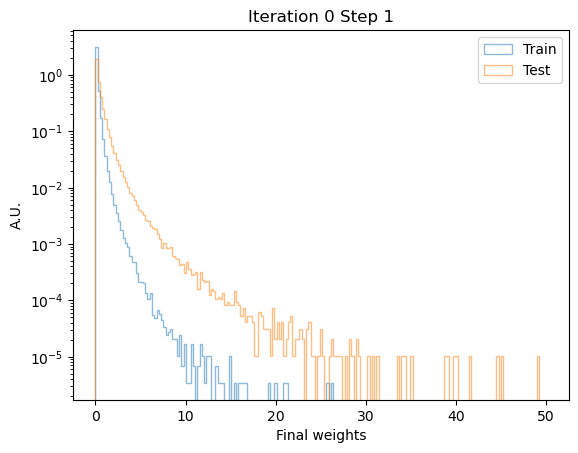

In [21]:
bins = np.linspace(0, 50, 200)
plt.hist(train_i0_s1_pass190, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
plt.hist(test_i0_s1_pass190, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Final weights')
plt.title('Iteration 0 Step 1')
plt.legend()
plt.show()

# bins = np.linspace(0, 20, 200)
# plt.hist(train_i1_s1_pass190, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
# plt.hist(test_i1_s1_pass190, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
# plt.yscale('log')
# plt.ylabel('A.U.')
# plt.xlabel('Omnifold weights')
# plt.title('Iteration 1 Step 1')
# plt.legend()
# plt.show()

# bins = np.linspace(0, 6, 200)
# plt.hist(train_i2_s1_pass190, bins=bins, density=True, histtype='step', label='Train', alpha=0.5)
# plt.hist(test_i2_s1_pass190, bins=bins, density=True, histtype='step', label='Test', alpha=0.5)
# plt.yscale('log')
# plt.ylabel('A.U.')
# plt.xlabel('Omnifold weights')
# plt.title('Iteration 2 Step 1')
# plt.legend()
# plt.show()

In [ ]:
# Make a plot of the i0_s1 and i1_s1 network weights, only fake events
train_i0_s1_fakes = train_i0_s1_all[train_pass190 == 0]
train_i1_s1_fakes = train_i1_s1_all[train_pass190 == 0]
train_i2_s1_fakes = train_i2_s1_all[train_pass190 == 0]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s1_fakes, bins=bins, density=True, histtype='step', label='i0_s1', alpha=0.5)
plt.hist(train_i1_s1_fakes, bins=bins, density=True, histtype='step', label='i1_s1', alpha=0.5)
plt.hist(train_i2_s1_fakes, bins=bins, density=True, histtype='step', label='i2_s1', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Fake Events')
plt.legend()
plt.show()

In [ ]:
# Get Omnifold weights for step 2 iterations
test_i0_s2_all = i0_s2['test'] / test_source_weights
test_i1_s2_all = i1_s2['test'] / test_source_weights
test_i2_s2_all = i2_s2['test'] / test_source_weights
train_i0_s2_all = i0_s2['train'] / train_source_weights
train_i1_s2_all = i1_s2['train'] / train_source_weights
train_i2_s2_all = i2_s2['train'] / train_source_weights

In [ ]:
# Make a plot of the i0_s2 and i1_s2 OF weights for testing set, with inefficien events removed
test_i0_s2_no_eff = test_i0_s2_all[test_truth_pass190 == 1]
test_i1_s2_no_eff = test_i1_s2_all[test_truth_pass190 == 1]
test_i2_s2_no_eff = test_i2_s2_all[test_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(test_i0_s2_no_eff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(test_i1_s2_no_eff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(test_i2_s2_no_eff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Test Set, Without Ineff')
plt.legend()
plt.show()

In [ ]:
# Make a plot of the i0_s2 and i1_s2 OF weights for training set, with inefficien events removed
train_i0_s2_no_eff = train_i0_s2_all[train_truth_pass190 == 1]
train_i1_s2_no_eff = train_i1_s2_all[train_truth_pass190 == 1]
train_i2_s2_no_eff = train_i2_s2_all[train_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s2_no_eff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(train_i1_s2_no_eff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(train_i2_s2_no_eff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Without Ineff')
plt.legend()
plt.show()

In [ ]:
# Make a plot of the i0_s2 and i1_s2 OF weights for the testing set, only ineff
test_i0_s2_ineff = test_i0_s2_all[test_truth_pass190 == 1]
test_i1_s2_ineff = test_i1_s2_all[test_truth_pass190 == 1]
test_i2_s2_ineff = test_i2_s2_all[test_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(test_i0_s2_ineff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(test_i1_s2_ineff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(test_i2_s2_ineff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Test Set, Ineff')
plt.legend()
plt.show()

In [ ]:
# Make a plot of the i0_s2 and i1_s2 OF weights for the training set, only ineff
train_i0_s2_ineff = train_i0_s2_all[train_truth_pass190 == 1]
train_i1_s2_ineff = train_i1_s2_all[train_truth_pass190 == 1]
train_i2_s2_ineff = train_i2_s2_all[train_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s2_ineff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(train_i1_s2_ineff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(train_i2_s2_ineff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Ineff')
plt.legend()
plt.show()